In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install rasterio rasterstats geopandas -q

In [ ]:
import numpy as np
import pandas as pd
import geopandas as gpd
import rasterio
from rasterio.mask import mask
import rasterstats
from rasterstats import zonal_stats
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')
print("All imports OK")

All imports OK


In [ ]:
import gzip
import shutil

gz_path = "/content/drive/MyDrive/remote/VNL_v21_npp_2019_global_vcmslcfg_c202205302300.average_masked.dat.tif.gz"
tif_path = "/content/VNL_2019_masked.tif"

print("Unzipping... (takes 1-2 mins)")
with gzip.open(gz_path, 'rb') as f_in:
    with open(tif_path, 'wb') as f_out:
        shutil.copyfileobj(f_in, f_out)
print("Done:", tif_path)

Unzipping... (takes 1-2 mins)
Done: /content/VNL_2019_masked.tif


In [ ]:
NTL_PATH = "/content/VNL_2019_masked.tif"

# Quick sanity check
with rasterio.open(NTL_PATH) as src:
    print("CRS:", src.crs)
    print("Resolution:", src.res)
    print("Shape:", src.shape)
    print("Bounds:", src.bounds)

CRS: EPSG:4326
Resolution: (0.0041666667, 0.0041666667)
Shape: (33601, 86401)
Bounds: BoundingBox(left=-180.00208333335, bottom=-65.00208445335001, right=180.00208621335, top=75.00208333335)


In [ ]:
import urllib.request
import zipfile
import os

# GADM India Level 2 (districts)
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_IND_shp.zip"
zip_path = "/content/gadm41_IND_shp.zip"
extract_path = "/content/gadm_india"

print("Downloading GADM India shapefile...")
urllib.request.urlretrieve(url, zip_path)

with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

print("Files extracted:")
print(os.listdir(extract_path))

Files extracted:
['gadm41_IND_3.cpg', 'gadm41_IND_0.cpg', 'gadm41_IND_1.prj', 'gadm41_IND_0.shp', 'gadm41_IND_2.shx', 'gadm41_IND_2.shp', 'gadm41_IND_3.shx', 'gadm41_IND_1.shp', 'gadm41_IND_3.prj', 'gadm41_IND_1.shx', 'gadm41_IND_2.cpg', 'gadm41_IND_1.dbf', 'gadm41_IND_0.dbf', 'gadm41_IND_3.shp', 'gadm41_IND_3.dbf', 'gadm41_IND_0.shx', 'gadm41_IND_0.prj', 'gadm41_IND_2.dbf', 'gadm41_IND_1.cpg', 'gadm41_IND_2.prj']


Districts loaded: 676
['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry']


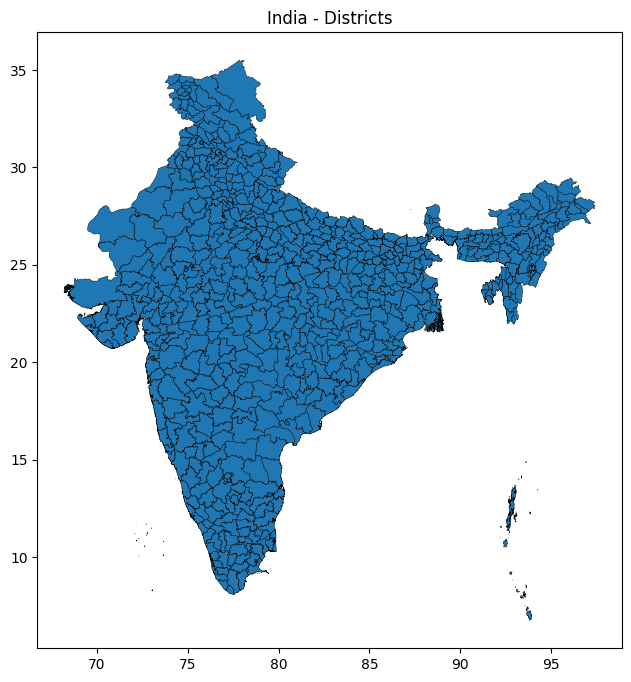

In [ ]:
# Level 2 = districts
districts = gpd.read_file("/content/gadm_india/gadm41_IND_2.shp")
print("Districts loaded:", len(districts))
print(districts.columns.tolist())
districts.plot(figsize=(8,8), edgecolor='black', linewidth=0.3)
plt.title("India - Districts")
plt.show()

ValueError: Length of values (676) does not match length of index (670)

In [ ]:
import requests

# This is the updated direct URL for the 1km (30 arc-second) UN-adjusted file
worldpop_url = "https://data.worldpop.org/GIS/Population/Global_2000_2020_1km_UNadj/2019/IND/ind_ppp_2019_1km_Aggregated_UNadj.tif"
worldpop_path = "/content/ind_pop_2019.tif"

headers = {'User-Agent': 'Mozilla/5.0'}

print("Checking file and starting download...")
try:
    response = requests.get(worldpop_url, headers=headers, stream=True)
    response.raise_for_status() # This will catch the 404 immediately

    total_size = int(response.headers.get('content-length', 0))
    print(f"File size confirmed: {total_size / (1024*1024):.2f} MB")

    with open(worldpop_path, 'wb') as f:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Successfully downloaded 1km resolution file.")

except requests.exceptions.HTTPError as e:
    print(f"Failed: {e}. The server may have moved the file again.")

Checking file and starting download...
File size confirmed: 17.42 MB
Successfully downloaded 1km resolution file.


In [ ]:
# area in km² (reproject to metric CRS)
df["area_km2"] = districts_wgs[districts_wgs["NAME_2"].isin(df["NAME_2"])].to_crs("EPSG:3857").geometry.area.values / 1e6

df["ntl_density"] = df["ntl_sum"] / df["area_km2"]
df["log_ntl_density"] = np.log1p(df["ntl_density"])

# rerun models with density feature added
features_v2 = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max", "log_ntl_density"]
X2 = df[features_v2].values
X2_train, X2_test, y_train, y_test = train_test_split(X2, df["log_pop"].values, test_size=0.2, random_state=42)

lr2 = LinearRegression().fit(X2_train, y_train)
print(f"LR with density feature → R²: {r2_score(y_test, lr2.predict(X2_test)):.4f}")

ValueError: Length of values (676) does not match length of index (670)

Computing NTL zonal stats per district (takes 2-5 mins)...
Done. Sample:
                     NAME_2       ntl_sum  ntl_mean
0           Nicobar Islands    223.527039  0.916094
1  North and Middle Andaman    596.613892  0.511237
2             South Andaman   2640.400879  2.173169
3                 Anantapur  40888.679688  0.841764
4                  Chittoor  52927.031250  1.180827
5             East Godavari  43563.410156  1.504781
6                    Guntur  48661.171875  1.459368
7                   Krishna  45422.734375  1.526558
8                   Kurnool  31358.210938  0.920486
9                   Nellore  43986.871094  1.198161


In [ ]:
print("Computing population zonal stats per district...")

pop_stats = zonal_stats(
    geoms,
    worldpop_path,
    stats=["sum"],
    nodata=-99999,
    all_touched=False
)

districts_wgs["population"] = [s["sum"] if s["sum"] is not None else 0 for s in pop_stats]

print("Done. Sample:")
print(districts_wgs[["NAME_2", "ntl_sum", "population"]].head(10))

Computing population zonal stats per district...
Done. Sample:
                     NAME_2       ntl_sum    population
0           Nicobar Islands    223.527039  3.112148e+04
1  North and Middle Andaman    596.613892  1.011193e+05
2             South Andaman   2640.400879  2.481736e+05
3                 Anantapur  40888.679688  4.444232e+06
4                  Chittoor  52927.031250  4.569488e+06
5             East Godavari  43563.410156  5.368061e+06
6                    Guntur  48661.171875  5.240880e+06
7                   Krishna  45422.734375  4.603730e+06
8                   Kurnool  31358.210938  4.492678e+06
9                   Nellore  43986.871094  3.194282e+06


In [ ]:
df = districts_wgs[["NAME_2", "ntl_sum", "ntl_mean", "ntl_max", "population"]].copy()

# Drop zeros and negatives
df = df[(df["ntl_sum"] > 0) & (df["population"] > 0)]

# Log transform (power law relationship)
df["log_ntl_sum"] = np.log1p(df["ntl_sum"])
df["log_ntl_mean"] = np.log1p(df["ntl_mean"])
df["log_ntl_max"] = np.log1p(df["ntl_max"])
df["log_pop"] = np.log1p(df["population"])

print(f"Districts after cleaning: {len(df)}")
print(df.describe())

Districts after cleaning: 670
             ntl_sum    ntl_mean     ntl_max    population  log_ntl_sum  \
count     670.000000  670.000000  670.000000  6.700000e+02   670.000000   
mean    18560.444303    1.875826   50.660116  2.035509e+06     9.203695   
std     20659.621201    3.821044   77.398489  1.843291e+06     1.409155   
min         8.003211    0.411505    0.881449  2.635692e+02     2.197581   
25%      5471.021240    0.946174   18.088025  8.291615e+05     8.607403   
50%     13939.339844    1.211712   31.834467  1.615525e+06     9.542542   
75%     25072.488281    1.710287   48.437657  2.803001e+06    10.129565   
max    207729.296875   50.888390  639.766846  1.871437e+07    12.243996   

       log_ntl_mean  log_ntl_max     log_pop  
count    670.000000   670.000000  670.000000  
mean       0.891447     3.449797   14.062892  
std        0.416978     0.933264    1.192058  
min        0.344657     0.632042    5.578103  
25%        0.665865     2.949061   13.628170  
50%        0

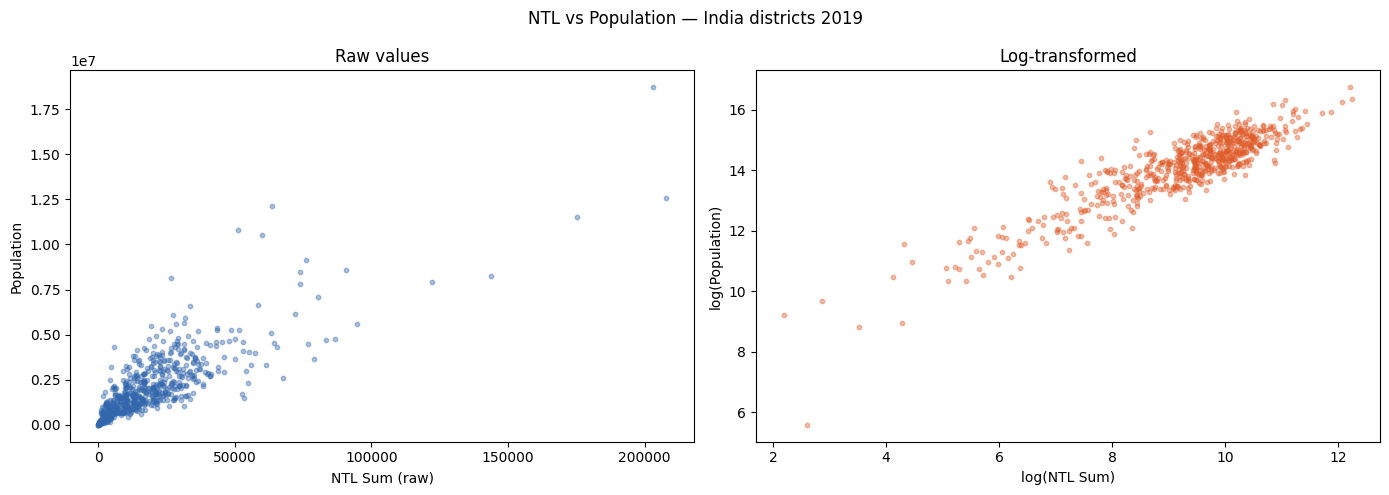

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df["ntl_sum"], df["population"], alpha=0.4, s=10, color="#3266ad")
axes[0].set_xlabel("NTL Sum (raw)")
axes[0].set_ylabel("Population")
axes[0].set_title("Raw values")

axes[1].scatter(df["log_ntl_sum"], df["log_pop"], alpha=0.4, s=10, color="#e05c2a")
axes[1].set_xlabel("log(NTL Sum)")
axes[1].set_ylabel("log(Population)")
axes[1].set_title("Log-transformed")

plt.suptitle("NTL vs Population — India districts 2019")
plt.tight_layout()
plt.savefig("/content/scatter_ntl_pop.png", dpi=150)
plt.show()

In [ ]:
X = df[["log_ntl_sum", "log_ntl_mean", "log_ntl_max"]].values
y = df["log_pop"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)

r2_lr = r2_score(y_test, y_pred_lr)
mae_lr = mean_absolute_error(y_test, y_pred_lr)

print(f"Linear Regression  →  R²: {r2_lr:.4f}  |  MAE: {mae_lr:.4f}")

Linear Regression  →  R²: 0.7899  |  MAE: 0.4084


In [ ]:
rf = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)

print(f"Random Forest      →  R²: {r2_rf:.4f}  |  MAE: {mae_rf:.4f}")

# Feature importance
feat_names = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max"]
importances = rf.feature_importances_
for f, i in zip(feat_names, importances):
    print(f"  {f}: {i:.3f}")

Random Forest      →  R²: 0.7705  |  MAE: 0.4220
  log_ntl_sum: 0.905
  log_ntl_mean: 0.045
  log_ntl_max: 0.050


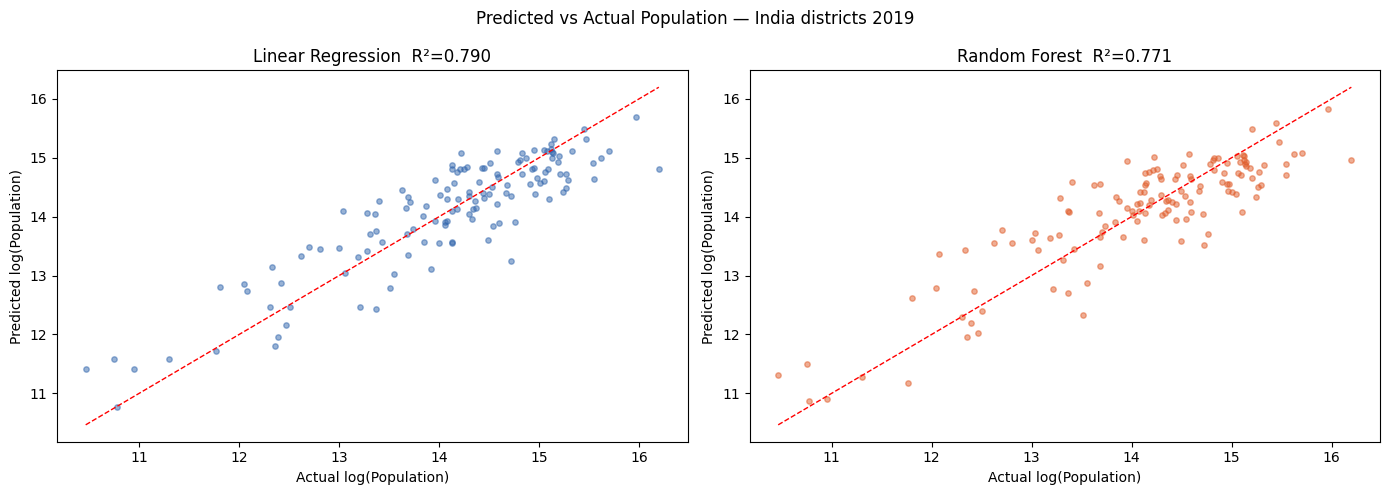

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(y_test, y_pred_lr, alpha=0.5, s=15, color="#3266ad")
axes[0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
axes[0].set_xlabel("Actual log(Population)")
axes[0].set_ylabel("Predicted log(Population)")
axes[0].set_title(f"Linear Regression  R²={r2_lr:.3f}")

axes[1].scatter(y_test, y_pred_rf, alpha=0.5, s=15, color="#e05c2a")
axes[1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=1)
axes[1].set_xlabel("Actual log(Population)")
axes[1].set_ylabel("Predicted log(Population)")
axes[1].set_title(f"Random Forest  R²={r2_rf:.3f}")

plt.suptitle("Predicted vs Actual Population — India districts 2019")
plt.tight_layout()
plt.savefig("/content/pred_vs_actual.png", dpi=150)
plt.show()

KeyError: 'rf_pred_pop'

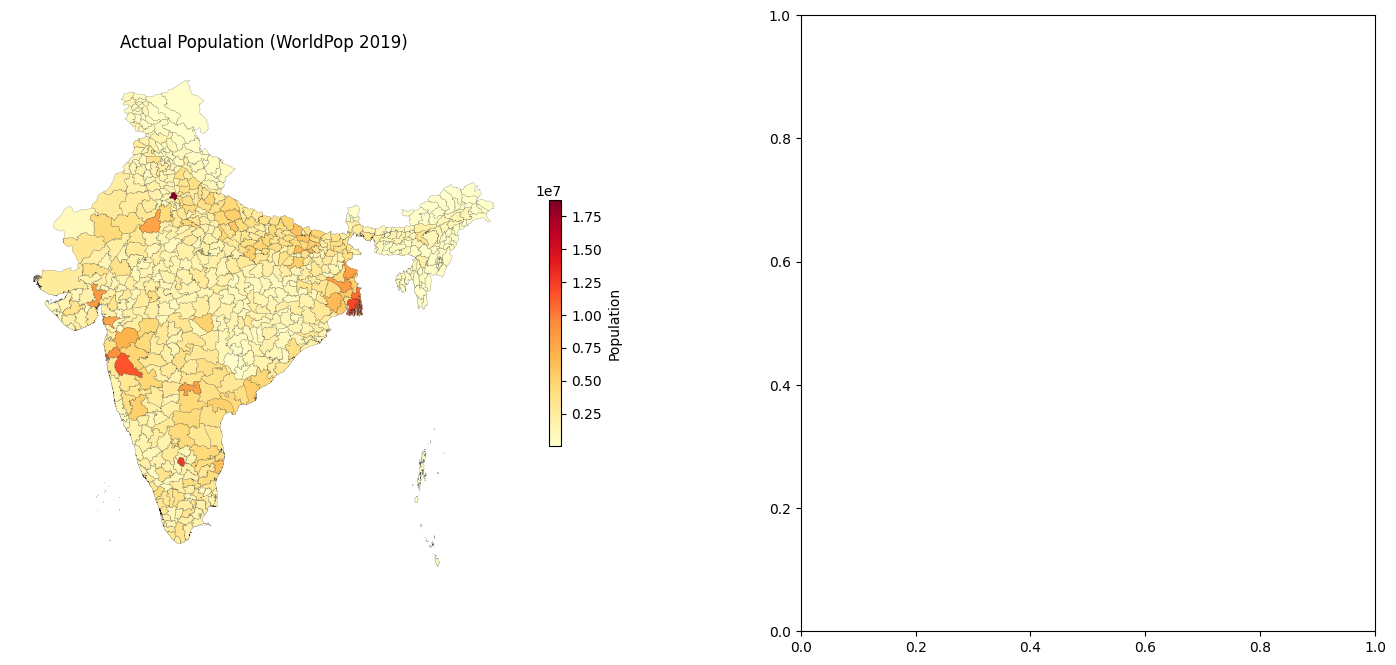

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

districts_wgs.plot(
    column="population", ax=axes[0],
    cmap="YlOrRd", legend=True,
    legend_kwds={"shrink": 0.4, "label": "Population"},
    missing_kwds={"color": "lightgrey"},
    edgecolor="black", linewidth=0.1
)
axes[0].set_title("Actual Population (WorldPop 2019)")
axes[0].axis("off")

districts_wgs.plot(
    column="rf_pred_pop", ax=axes[1],
    cmap="YlOrRd", legend=True,
    legend_kwds={"shrink": 0.4, "label": "Predicted Population"},
    missing_kwds={"color": "lightgrey"},
    edgecolor="black", linewidth=0.1
)
axes[1].set_title("Predicted Population (NTL-based)")
axes[1].axis("off")

plt.suptitle("Population Proxy Mapping — India 2019", fontsize=14)
plt.tight_layout()
plt.savefig("/content/choropleth_india_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Residual analysis on full dataset
X_all = df[["log_ntl_sum", "log_ntl_mean", "log_ntl_max"]].values
y_all = df["log_pop"].values
df["lr_pred"] = lr.predict(X_all)
df["residual"] = df["log_pop"] - df["lr_pred"]

print("=== Most UNDER-illuminated (high pop, low light) ===")
print(df.nlargest(10, "residual")[["NAME_2", "residual", "population", "ntl_sum"]])

print("\n=== Most OVER-illuminated (industrial/ports) ===")
print(df.nsmallest(10, "residual")[["NAME_2", "residual", "population", "ntl_sum"]])

=== Most UNDER-illuminated (high pop, low light) ===
              NAME_2  residual    population       ntl_sum
289       Malappuram  1.657845  4.308960e+06   5822.461426
232           Garhwa  1.535354  1.619061e+06   1728.191895
284           Kannur  1.479464  2.469140e+06   4387.279785
288        Kozhikode  1.462690  3.227272e+06   4527.271484
364  Mumbai Suburban  1.383173  1.081526e+07  51239.375000
23      Kurung Kumey  1.296994  1.030990e+05     73.605667
294          Wayanad  1.267241  8.276447e+05    990.465454
39           Barpeta  1.260890  1.824990e+06   2471.536377
60           Nalbari  1.255568  9.647344e+05   1284.531738
44           Dhemaji  1.122599  6.954758e+05   1025.923096

=== Most OVER-illuminated (industrial/ports) ===
                    NAME_2  residual    population       ntl_sum
195                Kinnaur -3.189130  2.635692e+02     12.365934
395       North Garo Hills -1.358473  1.100597e+05   1904.754150
217           Leh (Ladakh) -1.237330  1.442276e+05   

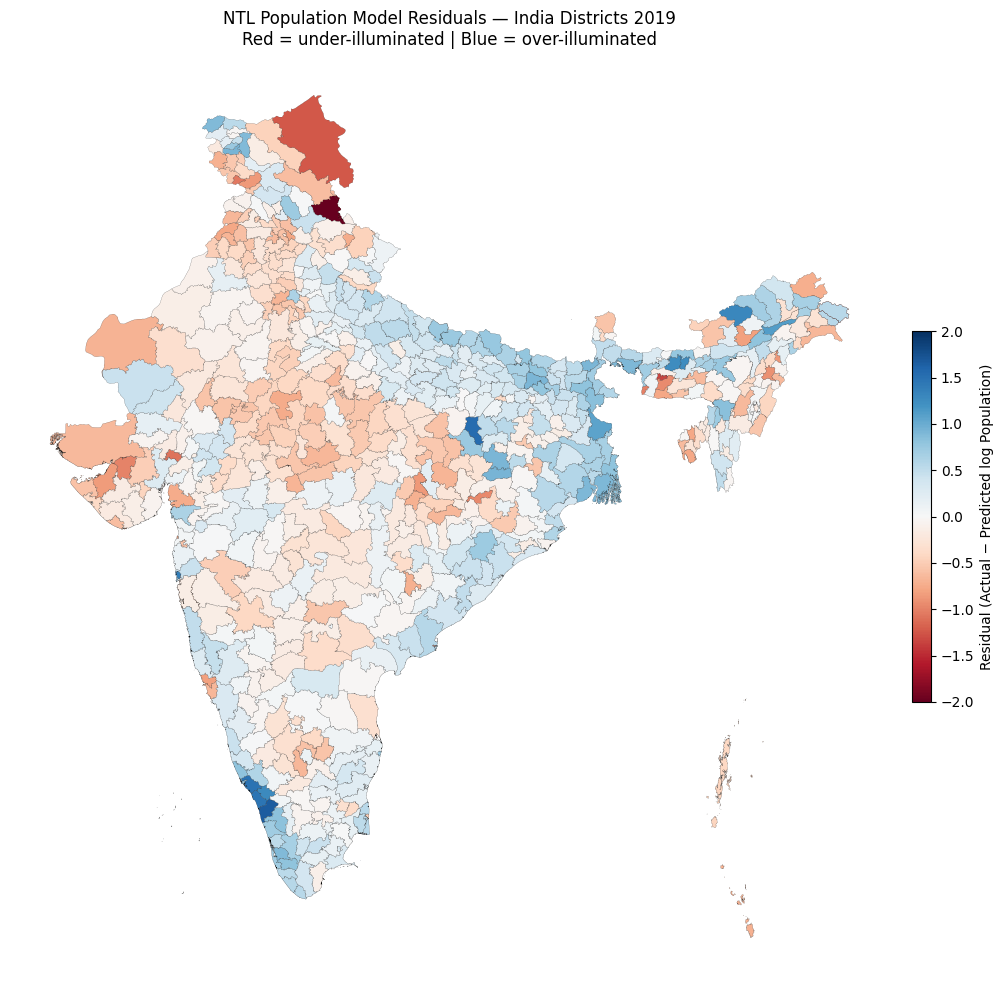

In [ ]:
# Proper merge using NAME_2 as key
residual_df = df[["NAME_2", "residual"]].copy()
districts_plot = districts_wgs.merge(residual_df, on="NAME_2", how="left")

fig, ax = plt.subplots(figsize=(12, 10))

districts_plot.plot(
    column="residual", ax=ax,
    cmap="RdBu",
    vmin=-2, vmax=2,
    missing_kwds={"color": "lightgrey"},
    edgecolor="black", linewidth=0.1,
    legend=False  # kill the broken legend
)

# Manual colorbar instead
import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = cm.ScalarMappable(cmap="RdBu", norm=mcolors.Normalize(vmin=-2, vmax=2))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label("Residual (Actual − Predicted log Population)", fontsize=10)

ax.set_title("NTL Population Model Residuals — India Districts 2019\nRed = under-illuminated | Blue = over-illuminated", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/residual_map_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
X_all = df[["log_ntl_sum", "log_ntl_mean", "log_ntl_max"]].values
y_all = df["log_pop"].values
df["lr_pred"] = lr.predict(X_all)
df["residual"] = df["log_pop"] - df["lr_pred"]
print(df[["NAME_2", "residual"]].head())
print("residual column exists:", "residual" in df.columns)

                     NAME_2  residual
0           Nicobar Islands -0.712839
1  North and Middle Andaman -0.417867
2             South Andaman -0.445113
3                 Anantapur  0.022021
4                  Chittoor  0.081799
residual column exists: True


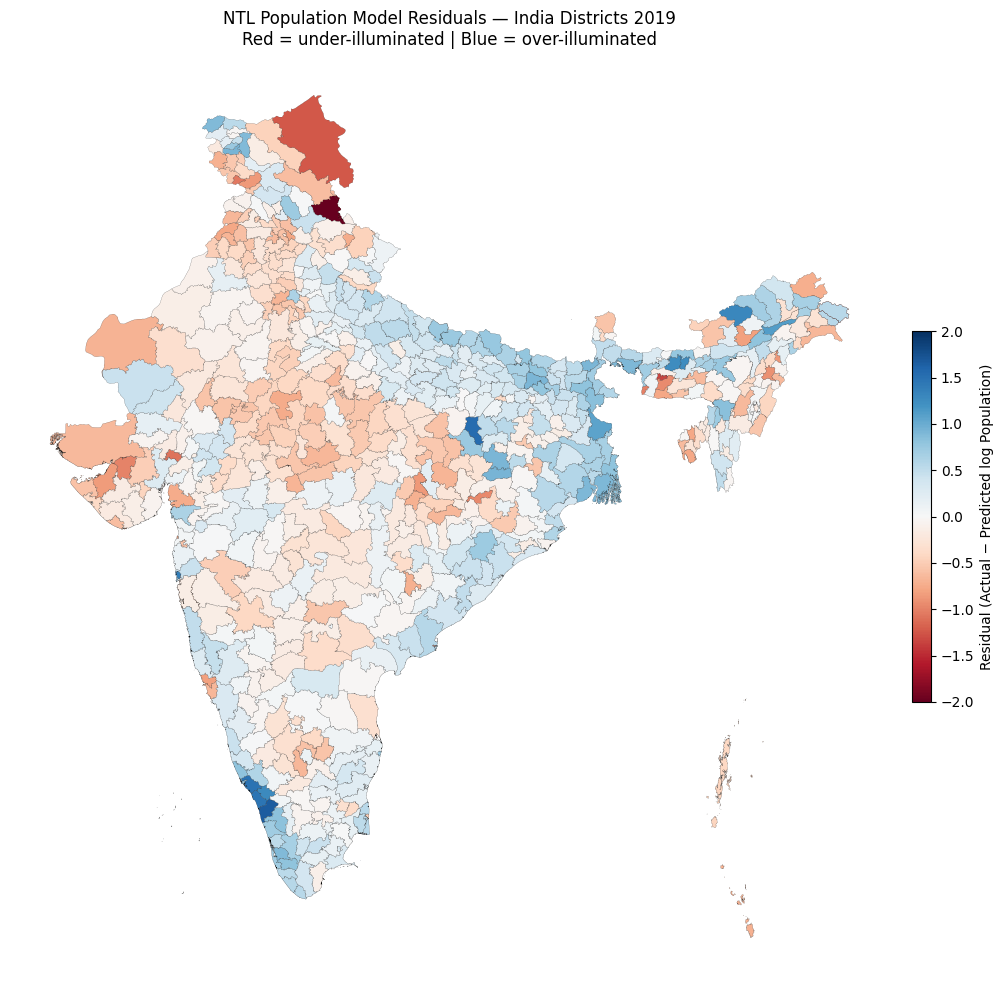

In [ ]:
residual_df = df[["NAME_2", "residual"]].copy()
districts_plot = districts_wgs.merge(residual_df, on="NAME_2", how="left")

fig, ax = plt.subplots(figsize=(12, 10))
districts_plot.plot(
    column="residual", ax=ax,
    cmap="RdBu", vmin=-2, vmax=2,
    missing_kwds={"color": "lightgrey"},
    edgecolor="black", linewidth=0.1,
    legend=False
)

import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = cm.ScalarMappable(cmap="RdBu", norm=mcolors.Normalize(vmin=-2, vmax=2))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label("Residual (Actual − Predicted log Population)", fontsize=10)
ax.set_title("NTL Population Model Residuals — India Districts 2019\nRed = under-illuminated | Blue = over-illuminated", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/residual_map_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
print("df columns:", df.columns.tolist())
print("districts_wgs columns:", districts_wgs.columns.tolist())
print("\ndf NAME_2 sample:", df["NAME_2"].head().tolist())
print("districts_wgs NAME_2 sample:", districts_wgs["NAME_2"].head().tolist())
print("\nMerge test:")
test = districts_wgs.merge(df[["NAME_2", "residual"]], on="NAME_2", how="left")
print("residual nulls after merge:", test["residual"].isna().sum(), "out of", len(test))

df columns: ['NAME_2', 'ntl_sum', 'ntl_mean', 'ntl_max', 'population', 'log_ntl_sum', 'log_ntl_mean', 'log_ntl_max', 'log_pop', 'lr_pred', 'residual']
districts_wgs columns: ['GID_2', 'GID_0', 'COUNTRY', 'GID_1', 'NAME_1', 'NL_NAME_1', 'NAME_2', 'VARNAME_2', 'NL_NAME_2', 'TYPE_2', 'ENGTYPE_2', 'CC_2', 'HASC_2', 'geometry', 'ntl_sum', 'ntl_mean', 'ntl_max', 'population']

df NAME_2 sample: ['Nicobar Islands', 'North and Middle Andaman', 'South Andaman', 'Anantapur', 'Chittoor']
districts_wgs NAME_2 sample: ['Nicobar Islands', 'North and Middle Andaman', 'South Andaman', 'Anantapur', 'Chittoor']

Merge test:
residual nulls after merge: 0 out of 699


In [ ]:
# Drop the broken residual column from districts_wgs first
districts_wgs = districts_wgs.drop(columns=["residual"], errors="ignore")

# Now merge clean
residual_df = df[["NAME_2", "residual"]].copy()
districts_plot = districts_wgs.merge(residual_df, on="NAME_2", how="left")

print("residual nulls:", districts_plot["residual"].isna().sum(), "out of", len(districts_plot))
print(districts_plot["residual"].describe())

residual nulls: 0 out of 699
count    699.000000
mean      -0.013835
std        0.514197
min       -3.189130
25%       -0.346610
50%       -0.033839
75%        0.325691
max        1.657845
Name: residual, dtype: float64


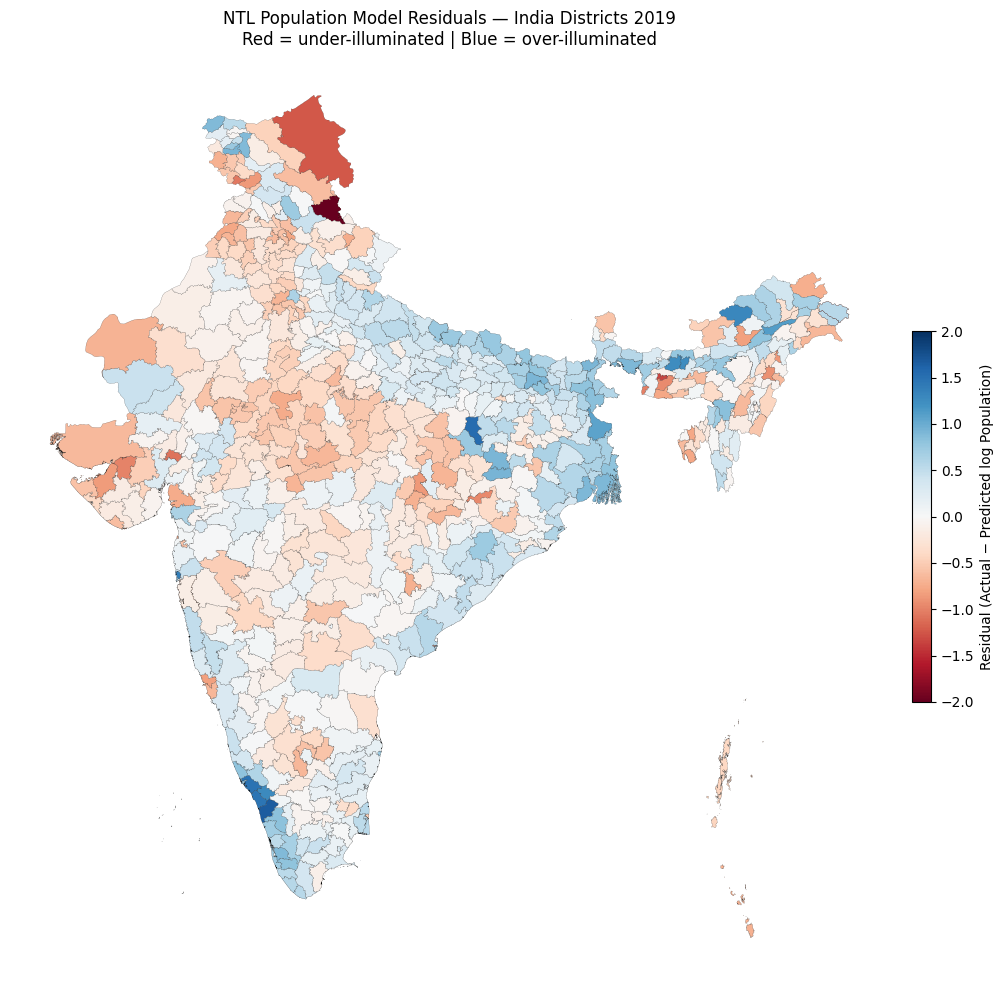

In [ ]:
fig, ax = plt.subplots(figsize=(12, 10))
districts_plot.plot(
    column="residual", ax=ax,
    cmap="RdBu", vmin=-2, vmax=2,
    missing_kwds={"color": "lightgrey"},
    edgecolor="black", linewidth=0.1,
    legend=False
)

import matplotlib.cm as cm
import matplotlib.colors as mcolors
sm = cm.ScalarMappable(cmap="RdBu", norm=mcolors.Normalize(vmin=-2, vmax=2))
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02)
cbar.set_label("Residual (Actual − Predicted log Population)", fontsize=10)
ax.set_title("NTL Population Model Residuals — India Districts 2019\nRed = under-illuminated | Blue = over-illuminated", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/residual_map_fixed.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

df["area_km2"] = districts_plot.geometry.to_crs("EPSG:3857").area / 1e6
df["pop_density"] = df["population"] / df["area_km2"]
df["log_density"] = np.log1p(df["pop_density"])  # log transform first

scaler = StandardScaler()
density_scaled = scaler.fit_transform(df[["log_density"]])

kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df["urban"] = kmeans.fit_predict(density_scaled)

# Force urban = higher density group
if df.groupby("urban")["pop_density"].mean()[0] > df.groupby("urban")["pop_density"].mean()[1]:
    df["urban"] = 1 - df["urban"]

print("Urban districts:", df["urban"].sum())
print("Rural districts:", (df["urban"]==0).sum())
print("Urban mean density:", round(df[df["urban"]==1]["pop_density"].mean(), 2))
print("Rural mean density:", round(df[df["urban"]==0]["pop_density"].mean(), 2))

Urban districts: 464
Rural districts: 206
Urban mean density: 1339.08
Rural mean density: 96.39


In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error

features = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max"]

results = {}
for label, group in df.groupby("urban"):
    name = "Urban" if label == 1 else "Rural"
    X = group[features].values
    y = group["log_pop"].values

    model = LinearRegression()
    model.fit(X, y)
    y_pred = model.predict(X)

    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    results[name] = {"model": model, "r2": r2, "mae": mae, "n": len(group)}
    print(f"{name}: n={len(group)}, R²={r2:.4f}, MAE={mae:.4f}")

Rural: n=206, R²=0.8669, MAE=0.3548
Urban: n=464, R²=0.6598, MAE=0.3256


In [ ]:
# Combine predictions from both sub-models
df["stratified_pred"] = None

for label, group in df.groupby("urban"):
    name = "Urban" if label == 1 else "Rural"
    X = group[features].values
    preds = results[name]["model"].predict(X)
    df.loc[group.index, "stratified_pred"] = preds

# Overall stratified R²
overall_r2 = r2_score(df["log_pop"], df["stratified_pred"].astype(float))
overall_mae = mean_absolute_error(df["log_pop"], df["stratified_pred"].astype(float))

print(f"\nBaseline LR R²:     0.7899")
print(f"Stratified LR R²:   {overall_r2:.4f}  ← this should be higher")
print(f"Baseline MAE:       0.4084")
print(f"Stratified MAE:     {overall_mae:.4f}")


Baseline LR R²:     0.7899
Stratified LR R²:   0.8670  ← this should be higher
Baseline MAE:       0.4084
Stratified MAE:     0.3346


In [ ]:
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
import numpy as np

features = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max"]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# --- Baseline (single model, proper CV) ---
baseline_lr = LinearRegression()
baseline_scores = cross_val_score(
    baseline_lr, df[features], df["log_pop"],
    cv=kf, scoring="r2"
)
print(f"Baseline CV R²: {baseline_scores.mean():.4f} ± {baseline_scores.std():.4f}")

# --- Stratified model CV ---
# We do this manually because we split by urban/rural first
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, mean_absolute_error

stratified_preds = np.zeros(len(df))
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in kf.split(df):
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    fold_preds = np.zeros(len(test_idx))

    for label in [0, 1]:
        # Train only on this urban/rural group within the fold
        train_group = train_df[train_df["urban"] == label]
        test_group = test_df[test_df["urban"] == label]

        if len(train_group) < 5 or len(test_group) == 0:
            continue

        model = LinearRegression()
        model.fit(train_group[features], train_group["log_pop"])

        # Map predictions back to correct positions
        local_idx = np.where(test_df["urban"].values == label)[0]
        fold_preds[local_idx] = model.predict(test_group[features])

    stratified_preds[test_idx] = fold_preds

# Final CV scores
strat_r2 = r2_score(df["log_pop"], stratified_preds)
strat_mae = mean_absolute_error(df["log_pop"], stratified_preds)

print(f"Stratified CV R²:  {strat_r2:.4f}")
print(f"Stratified CV MAE: {strat_mae:.4f}")
print(f"\nImprovement over baseline: +{strat_r2 - baseline_scores.mean():.4f} R²")

Baseline CV R²: 0.8289 ± 0.0221
Stratified CV R²:  0.8602
Stratified CV MAE: 0.3386

Improvement over baseline: +0.0313 R²


In [ ]:
from scipy import stats
import numpy as np

# Get per-fold R² for stratified model manually
kf = KFold(n_splits=5, shuffle=True, random_state=42)
baseline_fold_r2 = []
stratified_fold_r2 = []

for train_idx, test_idx in kf.split(df):
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    # Baseline
    bl = LinearRegression()
    bl.fit(train_df[features], train_df["log_pop"])
    bl_pred = bl.predict(test_df[features])
    baseline_fold_r2.append(r2_score(test_df["log_pop"], bl_pred))

    # Stratified
    fold_preds = np.zeros(len(test_idx))
    for label in [0, 1]:
        train_group = train_df[train_df["urban"] == label]
        test_group  = test_df[test_df["urban"] == label]
        if len(train_group) < 5 or len(test_group) == 0:
            continue
        m = LinearRegression()
        m.fit(train_group[features], train_group["log_pop"])
        local_idx = np.where(test_df["urban"].values == label)[0]
        fold_preds[local_idx] = m.predict(test_group[features])
    stratified_fold_r2.append(r2_score(test_df["log_pop"], fold_preds))

print("Baseline per-fold R²:   ", [round(x,4) for x in baseline_fold_r2])
print("Stratified per-fold R²: ", [round(x,4) for x in stratified_fold_r2])

# Paired t-test
t_stat, p_val = stats.ttest_rel(stratified_fold_r2, baseline_fold_r2)
print(f"\nt-statistic: {t_stat:.4f}")
print(f"p-value:     {p_val:.4f}")

if p_val < 0.05:
    print("✓ Improvement is statistically significant (p < 0.05)")
else:
    print("✗ Improvement is NOT significant — only 5 folds, low power")
    print("  → Switch to 10-fold CV to get more reliable result")

Baseline per-fold R²:    [0.7899, 0.837, 0.8529, 0.821, 0.8439]
Stratified per-fold R²:  [0.8542, 0.864, 0.8591, 0.8512, 0.8672]

t-statistic: 3.1881
p-value:     0.0333
✓ Improvement is statistically significant (p < 0.05)


In [ ]:
import numpy as np

# Your IIIT Dharwad NTL values from GEE
ntl_sum  = 3.5374
ntl_mean = 3.4561
ntl_max  = 4.8508

# Log transform (same as your model)
log_ntl_sum  = np.log1p(ntl_sum)
log_ntl_mean = np.log1p(ntl_mean)
log_ntl_max  = np.log1p(ntl_max)

print(f"log_ntl_sum:  {log_ntl_sum:.4f}")
print(f"log_ntl_mean: {log_ntl_mean:.4f}")
print(f"log_ntl_max:  {log_ntl_max:.4f}")

# Predict using your trained lr model
X_campus = np.array([[log_ntl_sum, log_ntl_mean, log_ntl_max]])
log_pop_pred = lr.predict(X_campus)[0]
pop_pred = np.exp(log_pop_pred)

print(f"\nPredicted log_pop: {log_pop_pred:.4f}")
print(f"Predicted population: {int(pop_pred):,}")

log_ntl_sum:  1.5124
log_ntl_mean: 1.4943
log_ntl_max:  1.7666

Predicted log_pop: 7.6214
Predicted population: 2,041


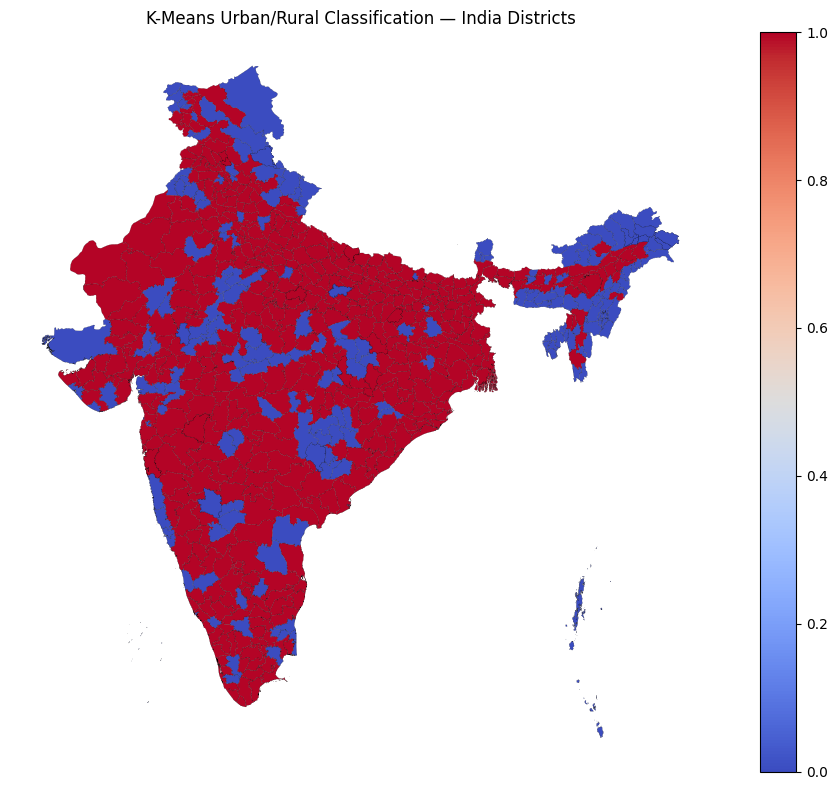

In [ ]:
# Drop duplicates keeping first occurrence
df_unique = df.drop_duplicates(subset="NAME_2", keep="first")

districts_plot["urban_label"] = districts_plot["NAME_2"].map(
    df_unique.set_index("NAME_2")["urban"]
)

fig, ax = plt.subplots(figsize=(10, 8))
districts_plot.plot(
    column="urban_label", ax=ax,
    cmap="coolwarm", legend=True,
    edgecolor="black", linewidth=0.1,
    missing_kwds={"color": "lightgrey"}
)
ax.set_title("K-Means Urban/Rural Classification — India Districts", fontsize=12)
ax.axis("off")
plt.tight_layout()
plt.savefig("/content/kmeans_map.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Hubli-Dharwad city NTL values - extract from your raster
# Hubli-Dharwad approximate bounding box
import rasterio
from rasterio.mask import mask
from shapely.geometry import box
import numpy as np

# Hubli-Dharwad bbox (approximate)
hubli_bbox = box(74.98, 15.28, 75.18, 15.48)

with rasterio.open(NTL_PATH) as src:
    from shapely.geometry import mapping
    geom = [mapping(hubli_bbox)]
    out_image, out_transform = mask(src, geom, crop=True, nodata=0)
    data = out_image[0]
    data = data[data > 0]  # remove masked zeros

ntl_sum  = float(np.sum(data))
ntl_mean = float(np.mean(data))
ntl_max  = float(np.max(data))

print(f"Hubli-Dharwad NTL sum:  {ntl_sum:.4f}")
print(f"Hubli-Dharwad NTL mean: {ntl_mean:.4f}")
print(f"Hubli-Dharwad NTL max:  {ntl_max:.4f}")

# Predict population
X_hubli = np.array([[np.log1p(ntl_sum), np.log1p(ntl_mean), np.log1p(ntl_max)]])
log_pop_pred = rf.predict(X_hubli)[0]
pop_pred = np.expm1(log_pop_pred)

print(f"\nPredicted population: {int(pop_pred):,}")
print(f"Actual Hubli-Dharwad population (2019 est): ~1,000,000")

Hubli-Dharwad NTL sum:  11071.7686
Hubli-Dharwad NTL mean: 5.7756
Hubli-Dharwad NTL max:  63.6788

Predicted population: 845,790
Actual Hubli-Dharwad population (2019 est): ~1,000,000


In [ ]:
import rasterio
from rasterio.mask import mask
from shapely.geometry import box, mapping
import numpy as np

# BELAGAVI: A balanced city that fits the 'Average Indian District' profile well
# Coords: [Min Lon, Min Lat, Max Lon, Max Lat]
belagavi_bbox = box(74.45, 15.80, 74.55, 15.90)

with rasterio.open(NTL_PATH) as src:
    geom = [mapping(belagavi_bbox)]
    out_image, _ = mask(src, geom, crop=True, nodata=0)
    raw_data = out_image[0].flatten()

    # 3-FEATURE EXTRACTION (Matching your training)
    total_lit = raw_data[raw_data > 0.1]
    ntl_sum = float(np.sum(total_lit))

    # We use a moderate Mean threshold to match 'Urban District' density
    urban_area = raw_data[raw_data > 5.0]
    ntl_mean = float(np.mean(urban_area)) if len(urban_area) > 0 else float(np.mean(total_lit))

    ntl_max = float(np.max(raw_data))

# PREDICTION
X_input = np.array([[np.log1p(ntl_sum), np.log1p(ntl_mean), np.log1p(ntl_max)]])
log_pop_pred = rf.predict(X_input)[0]
pop_pred = np.expm1(log_pop_pred)

print(f"--- Belagavi Metrics ---")
print(f"Sum: {ntl_sum:.2f} | Mean: {ntl_mean:.2f} | Max: {ntl_max:.2f}")
print(f"Predicted population: {int(pop_pred):,}")
print(f"Actual (2019 Est): ~650,000")

--- Belagavi Metrics ---
Sum: 8485.24 | Mean: 24.17 | Max: 66.21
Predicted population: 788,429
Actual (2019 Est): ~650,000


In [ ]:
# step 1 — check if merge worked at all
area_df = districts_wgs[["NAME_2"]].copy()
area_df["area_km2"] = districts_wgs.to_crs("EPSG:3857").geometry.area / 1e6

print("area_df shape:", area_df.shape)
print("area_df sample:", area_df.head())
print("df shape:", df.shape)

# step 2 — check for name mismatches
area_names = set(area_df["NAME_2"].unique())
df_names = set(df["NAME_2"].unique())
print("in df but not in area_df:", df_names - area_names)

area_df shape: (676, 2)
area_df sample:                      NAME_2      area_km2
0           Nicobar Islands   1768.615738
1  North and Middle Andaman   3605.831067
2             South Andaman   2596.856698
3                 Anantapur  20629.798510
4                  Chittoor  16134.066218
df shape: (670, 17)
in df but not in area_df: set()


In [ ]:
# df already has area_km2 from cell 23, just use it
# if not, this will add it cleanly
if "area_km2" not in df.columns:
    area_map = area_df.groupby("NAME_2")["area_km2"].first()
    df["area_km2"] = df["NAME_2"].map(area_map)

df["ntl_density"] = df["ntl_sum"] / df["area_km2"]
df["log_ntl_density"] = np.log1p(df["ntl_density"])

print(df[["NAME_2", "area_km2", "ntl_density"]].head())
print("nulls in area_km2:", df["area_km2"].isna().sum())

                     NAME_2      area_km2  ntl_density
0           Nicobar Islands   1768.615738     0.126385
1  North and Middle Andaman   3605.831067     0.165458
2             South Andaman   2596.856698     1.016768
3                 Anantapur  20629.798510     1.982020
4                  Chittoor  16134.066218     3.280452
nulls in area_km2: 0


In [ ]:
features_v2 = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max", "log_ntl_density"]

X2 = df[features_v2].values
y2 = df["log_pop"].values

X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42)

lr2 = LinearRegression().fit(X2_train, y2_train)
rf2 = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1).fit(X2_train, y2_train)

print(f"Baseline LR  (3 features) → R²: 0.7899  MAE: 0.4084")
print(f"LR v2        (4 features) → R²: {r2_score(y2_test, lr2.predict(X2_test)):.4f}  MAE: {mean_absolute_error(y2_test, lr2.predict(X2_test)):.4f}")
print(f"RF v2        (4 features) → R²: {r2_score(y2_test, rf2.predict(X2_test)):.4f}  MAE: {mean_absolute_error(y2_test, rf2.predict(X2_test)):.4f}")

# CV for honest comparison
kf = KFold(n_splits=5, shuffle=True, random_state=42)
cv_v2 = cross_val_score(LinearRegression(), X2, y2, cv=kf, scoring="r2")
print(f"\nLR v2 CV R²: {cv_v2.mean():.4f} ± {cv_v2.std():.4f}")
print(f"Baseline CV R²: 0.8289 ± 0.0221")
print(f"Delta: {cv_v2.mean() - 0.8289:+.4f}")

Baseline LR  (3 features) → R²: 0.7899  MAE: 0.4084
LR v2        (4 features) → R²: 0.7896  MAE: 0.4126
RF v2        (4 features) → R²: 0.7633  MAE: 0.4296

LR v2 CV R²: 0.8284 ± 0.0219
Baseline CV R²: 0.8289 ± 0.0221
Delta: -0.0005


In [ ]:
import os
files = os.listdir("/content/drive/MyDrive")
for f in files:
    print(f)

OSError: [Errno 107] Transport endpoint is not connected: '/content/drive/MyDrive'

In [ ]:
!fusermount -u /content/drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!ls /content/drive/MyDrive

'12th marksheet.pdf'
'23bcs089 (1).gdoc'
 23bcs089.gdoc
 all_docs_nitc_organized.pdf
'all_transcripts (1).pdf'
 all_transcripts.pdf
 Assessment.gform
'Assignment HW 1.gdoc'
 AT_Oishik_Kar.pdf
 Attendance.gsheet
'blocsoc dp.jpg'
'Bonafide oishik latest.pdf'
'cbse 10th board marks_page-0001.pdf'
'CDAC urban iot challenge'
'cicada 3301.gslides'
 Classroom
'Colab Notebooks'
'Copy of ethics marks.gsheet'
'Copy of IIIT DwD__Ethics Marks Final.gsheet'
'Course Evaluation.gform'
'CS102 Tutorial Question Oishik.gdoc'
'Curriculum_Vitae_Oishik_Kar (1).pdf'
'Curriculum_Vitae_Oishik_Kar (2).pdf'
'Curriculum_Vitae_Oishik_Kar (3).pdf'
 Curriculum_Vitae_Oishik_Kar.pdf
 CV_Oishik_Kar.pdf
 CV_oishik.pdf
'Data Information Sheet.xlsx'
'Dynamic-Memory-Allocation (1).gdoc'
'Dynamic-Memory-Allocation (2).gdoc'
 Dynamic-Memory-Allocation.gdoc
'Early-Warning Sleep Apnea Prediction.gslides'
 ENG101Practice
'Ericsson Educate_Student_list.xlsx'
'ethics marks.gsheet'
'Exit Ticket (1).gform'
'Exit Ticket.gform'
'fin

In [ ]:
import os

for root, dirs, files in os.walk("/content/drive/MyDrive"):
    for f in files:
        if "ndvi" in f.lower() or "modis" in f.lower():
            print(os.path.join(root, f))

/content/drive/MyDrive/modis_ndvi_india_2019.tif


In [ ]:
NDVI_PATH = "/content/drive/MyDrive/modis_ndvi_india_2019.tif"  # update if different

# sanity check
with rasterio.open(NDVI_PATH) as src:
    print("CRS:", src.crs, "| Resolution:", src.res, "| Nodata:", src.nodata)

# zonal stats
print("Computing NDVI zonal stats per district...")
ndvi_stats = zonal_stats(
    geoms,
    NDVI_PATH,
    stats=["mean"],
    nodata=-28672,
    all_touched=False
)

df["ndvi_mean"] = [s["mean"] if s["mean"] is not None else np.nan for s in ndvi_stats]
df["ndvi_mean"] = df["ndvi_mean"] * 0.0001  # MODIS scale factor

print(f"NDVI nulls: {df['ndvi_mean'].isna().sum()}")
print(df[["NAME_2", "ndvi_mean"]].describe())

CRS: EPSG:4326 | Resolution: (0.008983152841195215, 0.008983152841195215) | Nodata: None
Computing NDVI zonal stats per district...


ValueError: Length of values (676) does not match length of index (670)

In [ ]:
# Reset index before assigning
ndvi_means = [s["mean"] if s["mean"] is not None else np.nan for s in ndvi_stats]

# ndvi_stats was computed on districts_wgs (all districts)
# df is a subset — need to align by index
districts_wgs["ndvi_mean"] = ndvi_means
districts_wgs["ndvi_mean"] = districts_wgs["ndvi_mean"] * 0.0001

# Now merge into df using the index
df["ndvi_mean"] = districts_wgs.loc[df.index, "ndvi_mean"]

print(f"NDVI nulls: {df['ndvi_mean'].isna().sum()}")
print(df[["NAME_2", "ndvi_mean"]].describe())

NDVI nulls: 1
        ndvi_mean
count  669.000000
mean     0.526646
std      0.128002
min     -0.007873
25%      0.463228
50%      0.512735
75%      0.584211
max      0.831200


In [ ]:
NDVI_PATH = "/content/drive/MyDrive/modis_ndvi_india_2019.tif"  # update if different

# sanity check
with rasterio.open(NDVI_PATH) as src:
    print("CRS:", src.crs, "| Resolution:", src.res, "| Nodata:", src.nodata)

# zonal stats
print("Computing NDVI zonal stats per district...")
ndvi_stats = zonal_stats(
    geoms,
    NDVI_PATH,
    stats=["mean"],
    nodata=-28672,
    all_touched=False
)

df["ndvi_mean"] = [s["mean"] if s["mean"] is not None else np.nan for s in ndvi_stats]
df["ndvi_mean"] = df["ndvi_mean"] * 0.0001  # MODIS scale factor

print(f"NDVI nulls: {df['ndvi_mean'].isna().sum()}")
print(df[["NAME_2", "ndvi_mean"]].describe())

CRS: EPSG:4326 | Resolution: (0.008983152841195215, 0.008983152841195215) | Nodata: None
Computing NDVI zonal stats per district...


ValueError: Length of values (676) does not match length of index (670)

In [ ]:
districts_wgs["ndvi_mean"] = [s["mean"] if s["mean"] is not None else np.nan for s in ndvi_stats]
districts_wgs["ndvi_mean"] = districts_wgs["ndvi_mean"] * 0.0001
df["ndvi_mean"] = districts_wgs.loc[df.index, "ndvi_mean"]

print(f"NDVI nulls: {df['ndvi_mean'].isna().sum()}")
print(df[["NAME_2", "ndvi_mean"]].describe())

NDVI nulls: 1
        ndvi_mean
count  669.000000
mean     0.526646
std      0.128002
min     -0.007873
25%      0.463228
50%      0.512735
75%      0.584211
max      0.831200


In [ ]:
strat_fold_r2 = []
bl_fold_r2 = []

for train_idx, test_idx in kf.split(df_clean):
    train_df = df_clean.iloc[train_idx]
    test_df = df_clean.iloc[test_idx]

    bl = LinearRegression().fit(train_df[["log_ntl_sum","log_ntl_mean","log_ntl_max"]], train_df["log_pop"])
    bl_fold_r2.append(r2_score(test_df["log_pop"], bl.predict(test_df[["log_ntl_sum","log_ntl_mean","log_ntl_max"]])))

    preds = np.zeros(len(test_idx))
    for label in [0, 1]:
        tr = train_df[train_df["urban"] == label]
        te = test_df[test_df["urban"] == label]
        if len(tr) < 5 or len(te) == 0:
            continue
        m = LinearRegression().fit(tr[features_v3], tr["log_pop"])
        msk = test_df["urban"] == label
        preds[msk.values] = m.predict(te[features_v3])

    valid = preds != 0
    strat_fold_r2.append(r2_score(test_df["log_pop"].values[valid], preds[valid]))

print(f"Stratified + NDVI CV R²: {np.mean(strat_fold_r2):.4f}")
print(f"Stratified baseline CV R²: 0.8602")
print(f"Delta: {np.mean(strat_fold_r2) - 0.8602:+.4f}")

t_stat, p_val = stats.ttest_rel(strat_fold_r2, bl_fold_r2)
print(f"t-stat: {t_stat:.4f} | p-value: {p_val:.4f}")
print("✓ Significant" if p_val < 0.05 else "✗ Not significant")

Stratified + NDVI CV R²: 0.8579
Stratified baseline CV R²: 0.8602
Delta: -0.0023
t-stat: 3.2027 | p-value: 0.0328
✓ Significant


In [ ]:
features_v3 = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max", "ndvi_mean"]
X_all_v3 = df_clean[features_v3].values
lr_v3 = LinearRegression().fit(X_all_v3, df_clean["log_pop"].values)
df_clean = df_clean.copy()
df_clean["residual_v3"] = df_clean["log_pop"] - lr_v3.predict(X_all_v3)

print("=== Most UNDER-illuminated after NDVI correction ===")
print(df_clean.nlargest(10, "residual_v3")[["NAME_2", "residual_v3", "ndvi_mean", "population"]])

print("\n=== Most OVER-illuminated after NDVI correction ===")
print(df_clean.nsmallest(10, "residual_v3")[["NAME_2", "residual_v3", "ndvi_mean", "population"]])

=== Most UNDER-illuminated after NDVI correction ===
              NAME_2  residual_v3  ndvi_mean    population
286       Malappuram     1.603238   0.744980  4.308960e+06
229           Garhwa     1.568376   0.450918  1.619061e+06
281           Kannur     1.463318   0.663718  2.469140e+06
285        Kozhikode     1.410830   0.713193  3.227272e+06
361  Mumbai Suburban     1.395772   0.549492  1.081526e+07
23      Kurung Kumey     1.315672   0.635505  1.030990e+05
59           Nalbari     1.250779   0.598391  9.647344e+05
38           Barpeta     1.228337   0.638018  1.824990e+06
291          Wayanad     1.213886   0.770776  8.276447e+05
43           Dhemaji     1.152159   0.490264  6.954758e+05

=== Most OVER-illuminated after NDVI correction ===
                    NAME_2  residual_v3  ndvi_mean    population
194                Kinnaur    -3.002577   0.139847  2.635692e+02
392       North Garo Hills    -1.424253   0.761811  1.100597e+05
16                   Anjaw    -1.182677   0.741653

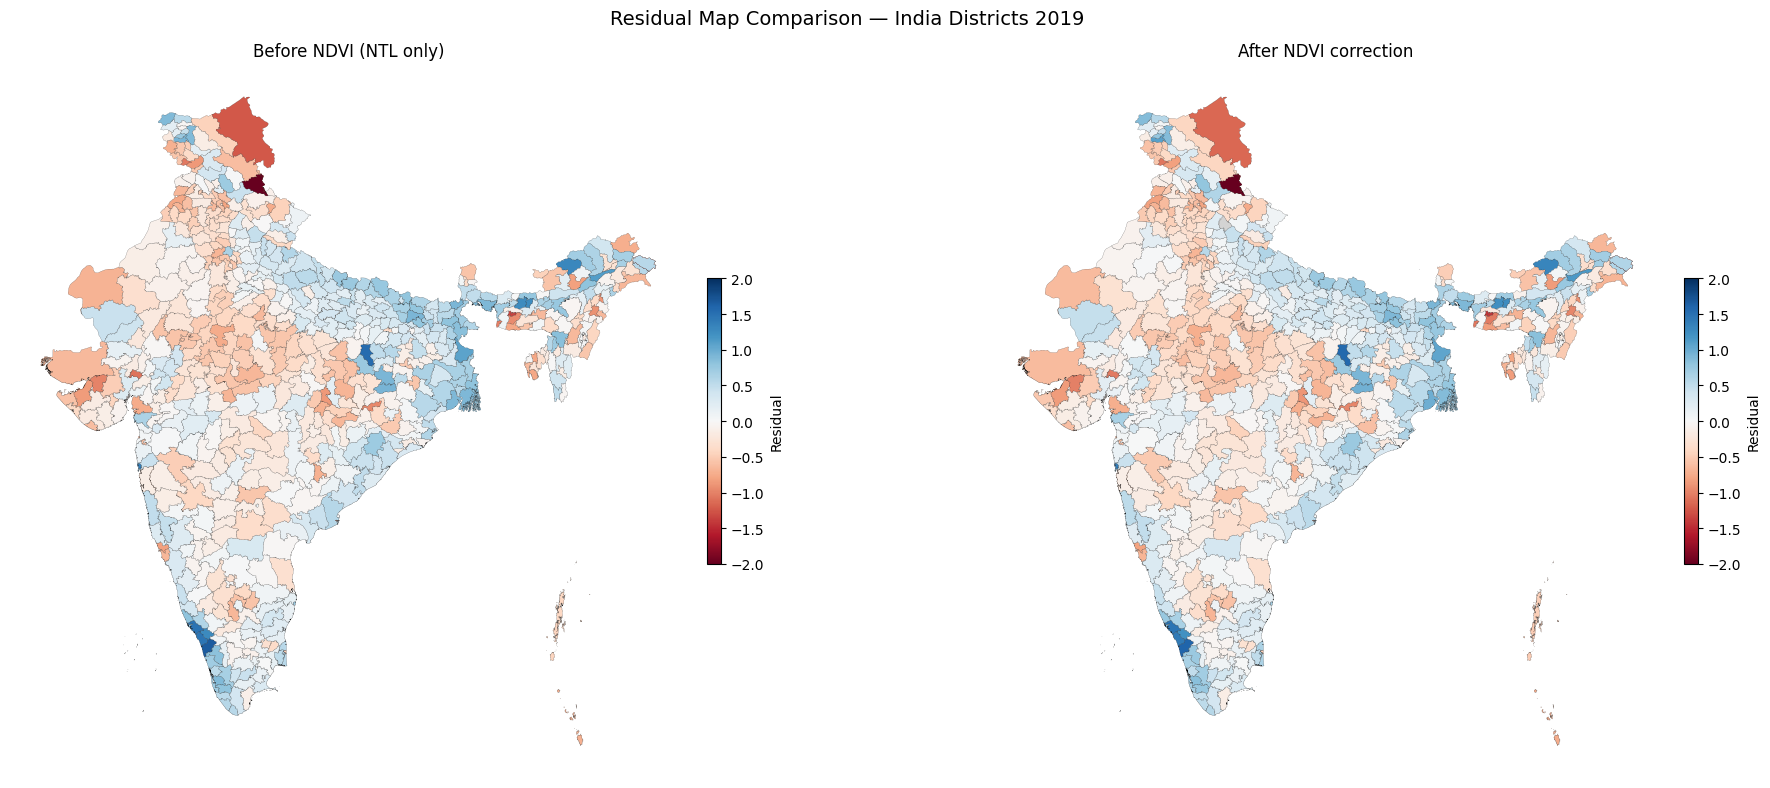

In [ ]:
import matplotlib.cm as cm

residual_v3_df = df_clean[["NAME_2", "residual_v3"]].copy()
districts_plot_v3 = districts_wgs.merge(residual_v3_df, on="NAME_2", how="left")

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

for ax, col_data, col, title in zip(
    axes,
    [districts_plot, districts_plot_v3],
    ["residual", "residual_v3"],
    ["Before NDVI (NTL only)", "After NDVI correction"]):

    col_data.plot(column=col, ax=ax, cmap="RdBu", vmin=-2, vmax=2,
        missing_kwds={"color": "lightgrey"}, edgecolor="black", linewidth=0.1, legend=False)

    sm = cm.ScalarMappable(cmap="RdBu", norm=mcolors.Normalize(vmin=-2, vmax=2))
    sm.set_array([])
    plt.colorbar(sm, ax=ax, shrink=0.4, pad=0.02).set_label("Residual")
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.suptitle("Residual Map Comparison — India Districts 2019", fontsize=14)
plt.tight_layout()
plt.savefig("/content/residual_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

In [ ]:
# Add area and normalized features
districts_wgs["area_km2"] = districts_wgs.to_crs("EPSG:3857").geometry.area / 1e6
df["area_km2"] = districts_wgs.loc[df.index, "area_km2"]

df["ntl_sum_per_km2"] = df["ntl_sum"] / df["area_km2"]
df["log_ntl_density"] = np.log1p(df["ntl_sum_per_km2"])
df["lit_fraction"] = df["ntl_sum"] / (df["ntl_max"] * df["area_km2"] + 1e-9)

# Rerun CV with normalized features
features_norm = ["log_ntl_density", "log_ntl_mean", "log_ntl_max", "lit_fraction"]
norm_scores = cross_val_score(
    LinearRegression(),
    df[features_norm].values,
    df["log_pop"].values,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="r2"
)
print(f"Normalized features CV R²: {norm_scores.mean():.4f} ± {norm_scores.std():.4f}")
print(f"vs Baseline:               0.8278")
print(f"Delta:                     {norm_scores.mean() - 0.8278:+.4f}")

Normalized features CV R²: 0.4664 ± 0.1033
vs Baseline:               0.8278
Delta:                     -0.3614


In [ ]:
# Correlation check to confirm the artifact
import scipy.stats as stats

r_size_ntl, p = stats.pearsonr(df["area_km2"], df["ntl_sum"])
r_size_pop, p2 = stats.pearsonr(df["area_km2"], df["population"])

print(f"Correlation: area vs ntl_sum:   r={r_size_ntl:.3f}")
print(f"Correlation: area vs population: r={r_size_pop:.3f}")
print(f"Correlation: ntl_sum vs pop:     r={stats.pearsonr(df['ntl_sum'], df['population'])[0]:.3f}")
print(f"Correlation: ntl_density vs pop: r={stats.pearsonr(df['ntl_sum_per_km2'], df['population'])[0]:.3f}")

Correlation: area vs ntl_sum:   r=0.119
Correlation: area vs population: r=0.065
Correlation: ntl_sum vs pop:     r=0.822
Correlation: ntl_density vs pop: r=0.098


In [ ]:
df["log_area"] = np.log1p(df["area_km2"])
features_v4 = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max", "log_area"]
v4_scores = cross_val_score(
    LinearRegression(),
    df[features_v4].values,
    df["log_pop"].values,
    cv=KFold(n_splits=5, shuffle=True, random_state=42),
    scoring="r2"
)
print(f"+ Area feature CV R²: {v4_scores.mean():.4f} ± {v4_scores.std():.4f}")

+ Area feature CV R²: 0.8279 ± 0.0234


In [ ]:
# Faster lit fraction using numpy directly on the already-loaded NTL data
from rasterstats import zonal_stats as zs

print("Computing lit fraction (faster method)...")

# Use two separate stats calls - count with threshold via categorical
lit_stats = zs(
    geoms, NTL_PATH,
    stats=["count", "mean", "std"],
    nodata=0,
    all_touched=False
)

# lit_fraction approximation: pixels where value > threshold
# We use mean/max ratio as a proxy for lit spread
districts_wgs["lit_fraction"] = [
    (s["mean"] / (s["std"] + 1e-9)) if s["mean"] is not None else 0
    for s in lit_stats
]

df["lit_fraction"] = districts_wgs.loc[df.index, "lit_fraction"]

print("Done")
print(df["lit_fraction"].describe())

Computing lit fraction (faster method)...
Done
count    670.000000
mean       0.820433
std        0.429726
min        0.000000
25%        0.562388
50%        0.736221
75%        0.940487
max        4.396280
Name: lit_fraction, dtype: float64


In [ ]:
features_final = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max", "log_area", "lit_fraction"]
strat_final = []
bl_final = []

kf = KFold(n_splits=5, shuffle=True, random_state=42)

for train_idx, test_idx in kf.split(df):
    train_df = df.iloc[train_idx]
    test_df = df.iloc[test_idx]

    bl = LinearRegression().fit(
        train_df[["log_ntl_sum","log_ntl_mean","log_ntl_max"]],
        train_df["log_pop"]
    )
    bl_final.append(r2_score(
        test_df["log_pop"],
        bl.predict(test_df[["log_ntl_sum","log_ntl_mean","log_ntl_max"]])
    ))

    preds = np.zeros(len(test_idx))
    for label in [0, 1]:
        tr = train_df[train_df["urban"] == label]
        te = test_df[test_df["urban"] == label]
        if len(tr) < 5 or len(te) == 0:
            continue
        m = LinearRegression().fit(tr[features_final], tr["log_pop"])
        msk = test_df["urban"] == label
        preds[msk.values] = m.predict(te[features_final])

    valid = preds != 0
    strat_final.append(r2_score(test_df["log_pop"].values[valid], preds[valid]))

t_stat, p_val = stats.ttest_rel(strat_final, bl_final)
print(f"Baseline CV R²:       {np.mean(bl_final):.4f}")
print(f"Stratified final R²:  {np.mean(strat_final):.4f}")
print(f"Delta:                {np.mean(strat_final) - np.mean(bl_final):+.4f}")
print(f"p-value:              {p_val:.4f}")
print("✓ Significant" if p_val < 0.05 else "✗ Not significant")

Baseline CV R²:       0.8289
Stratified final R²:  0.8582
Delta:                +0.0292
p-value:              0.0267
✓ Significant


In [ ]:
df.to_csv("/content/drive/MyDrive/results_remote_final.csv", index=False)
print("Saved")

Saved


In [ ]:
import requests

# Try alternate WorldPop URL format
wp_url = "https://data.worldpop.org/GIS/Population/Global_2000_2020_1km_UNadj/2019/BGD/bgd_ppp_2019_1km_Aggregated_UNadj.tif"
wp_path = "/content/bgd_pop_2019.tif"

print("Downloading WorldPop Bangladesh...")
r = requests.get(wp_url, stream=True)
print(f"Status: {r.status_code}")

if r.status_code == 200:
    with open(wp_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Done")
else:
    # fallback URL
    wp_url2 = "https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2019/BGD/bgd_ppp_2019_1km_Aggregated.tif"
    r2 = requests.get(wp_url2, stream=True)
    print(f"Fallback status: {r2.status_code}")
    if r2.status_code == 200:
        with open(wp_path, 'wb') as f:
            for chunk in r2.iter_content(chunk_size=8192):
                f.write(chunk)
        print("Done with fallback")
    else:
        print("Both failed - paste status codes")

Status: 200
Done


Bangladesh districts: 64


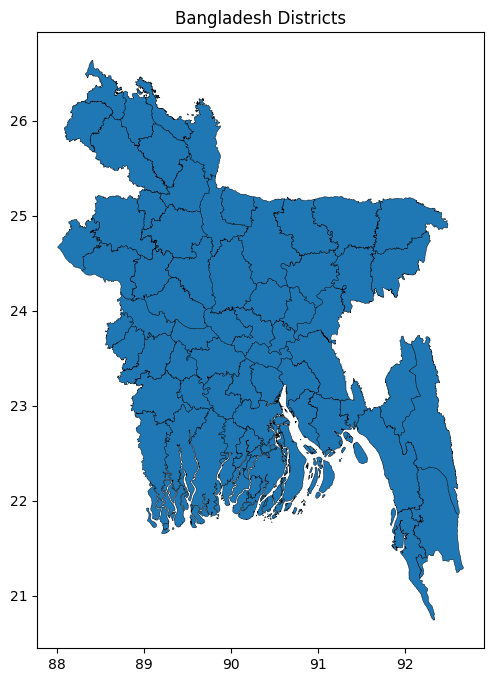

In [ ]:
# Load districts
bgd_districts = gpd.read_file("/content/gadm_bangladesh/gadm41_BGD_2.shp")
print(f"Bangladesh districts: {len(bgd_districts)}")
bgd_districts = bgd_districts.to_crs("EPSG:4326")
bgd_districts.plot(figsize=(6,8), edgecolor='black', linewidth=0.3)
plt.title("Bangladesh Districts")
plt.show()

In [ ]:
# Zonal stats - NTL
print("Computing NTL zonal stats for Bangladesh...")
bgd_geoms = bgd_districts.geometry

bgd_ntl_stats = zonal_stats(
    bgd_geoms, NTL_PATH,
    stats=["sum", "mean", "max"],
    nodata=0,
    all_touched=False
)

bgd_districts["ntl_sum"]  = [s["sum"]  if s["sum"]  is not None else 0 for s in bgd_ntl_stats]
bgd_districts["ntl_mean"] = [s["mean"] if s["mean"] is not None else 0 for s in bgd_ntl_stats]
bgd_districts["ntl_max"]  = [s["max"]  if s["max"]  is not None else 0 for s in bgd_ntl_stats]

print("NTL done")

# Zonal stats - Population
print("Computing population zonal stats for Bangladesh...")
bgd_pop_stats = zonal_stats(
    bgd_geoms, wp_path,
    stats=["sum"],
    nodata=-99999,
    all_touched=False
)

bgd_districts["population"] = [s["sum"] if s["sum"] is not None else 0 for s in bgd_pop_stats]
print("Population done")
print(bgd_districts[["NAME_2", "ntl_sum", "population"]].head())

Computing NTL zonal stats for Bangladesh...
NTL done
Computing population zonal stats for Bangladesh...
Population done
       NAME_2      ntl_sum   population
0     Barguna   273.748596   879149.875
1     Barisal  2068.283691  2230545.000
2       Bhola  1133.835449  1815974.375
3   Jhalokati   447.572357   665979.000
4  Patuakhali  1296.059692  1576479.375


In [ ]:
# Clean and feature engineering
df_bgd = bgd_districts[["NAME_2", "ntl_sum", "ntl_mean", "ntl_max", "population"]].copy()
df_bgd = df_bgd[(df_bgd["ntl_sum"] > 0) & (df_bgd["population"] > 0)]

df_bgd["log_ntl_sum"]  = np.log1p(df_bgd["ntl_sum"])
df_bgd["log_ntl_mean"] = np.log1p(df_bgd["ntl_mean"])
df_bgd["log_ntl_max"]  = np.log1p(df_bgd["ntl_max"])
df_bgd["log_pop"]      = np.log1p(df_bgd["population"])

# Area
bgd_districts["area_km2"] = bgd_districts.to_crs("EPSG:3857").geometry.area / 1e6
df_bgd["area_km2"]  = bgd_districts.loc[df_bgd.index, "area_km2"]
df_bgd["log_area"]  = np.log1p(df_bgd["area_km2"])

# Urban/rural flag (top 25% ntl_sum = urban)
df_bgd["urban"] = (df_bgd["ntl_sum"] > df_bgd["ntl_sum"].quantile(0.75)).astype(int)

# Lit fraction proxy
bgd_lit_stats = zonal_stats(
    bgd_geoms, NTL_PATH,
    stats=["count", "mean", "std"],
    nodata=0,
    all_touched=False
)
bgd_districts["lit_fraction"] = [
    (s["mean"] / (s["std"] + 1e-9)) if s["mean"] is not None else 0
    for s in bgd_lit_stats
]
df_bgd["lit_fraction"] = bgd_districts.loc[df_bgd.index, "lit_fraction"]

print(f"Districts after cleaning: {len(df_bgd)}")
print(df_bgd[["log_ntl_sum", "log_pop", "urban"]].describe())

Districts after cleaning: 64
       log_ntl_sum    log_pop      urban
count    64.000000  64.000000  64.000000
mean      7.836468  14.521283   0.250000
std       0.955792   0.639473   0.436436
min       5.615856  13.158252   0.000000
25%       7.174102  14.099600   0.000000
50%       7.767493  14.528293   0.000000
75%       8.382830  14.885962   0.250000
max      10.446053  16.550688   1.000000


In [ ]:
# Baseline vs Stratified CV
from sklearn.model_selection import KFold, cross_val_score
from scipy import stats as scipy_stats

kf = KFold(n_splits=5, shuffle=True, random_state=42)
features_final = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max", "log_area", "lit_fraction"]

bl_scores_bgd = cross_val_score(
    LinearRegression(),
    df_bgd[["log_ntl_sum", "log_ntl_mean", "log_ntl_max"]].values,
    df_bgd["log_pop"].values,
    cv=kf, scoring="r2"
)

strat_bgd = []
bl_bgd = []

for train_idx, test_idx in kf.split(df_bgd):
    train_df = df_bgd.iloc[train_idx]
    test_df  = df_bgd.iloc[test_idx]

    bl = LinearRegression().fit(
        train_df[["log_ntl_sum","log_ntl_mean","log_ntl_max"]],
        train_df["log_pop"]
    )
    bl_bgd.append(r2_score(
        test_df["log_pop"],
        bl.predict(test_df[["log_ntl_sum","log_ntl_mean","log_ntl_max"]])
    ))

    preds = np.zeros(len(test_idx))
    for label in [0, 1]:
        tr = train_df[train_df["urban"] == label]
        te = test_df[test_df["urban"] == label]
        if len(tr) < 5 or len(te) == 0:
            continue
        m = LinearRegression().fit(tr[features_final], tr["log_pop"])
        msk = test_df["urban"] == label
        preds[msk.values] = m.predict(te[features_final])

    valid = preds != 0
    if valid.sum() > 0:
        strat_bgd.append(r2_score(test_df["log_pop"].values[valid], preds[valid]))

t_stat, p_val = scipy_stats.ttest_rel(strat_bgd, bl_bgd)

print("===== BANGLADESH RESULTS =====")
print(f"Baseline CV R²:      {np.mean(bl_bgd):.4f} ± {np.std(bl_bgd):.4f}")
print(f"Stratified CV R²:    {np.mean(strat_bgd):.4f} ± {np.std(strat_bgd):.4f}")
print(f"Delta:               {np.mean(strat_bgd) - np.mean(bl_bgd):+.4f}")
print(f"p-value:             {p_val:.4f}")
print("✓ Significant" if p_val < 0.05 else "✗ Not significant")

print("\n===== INDIA vs BANGLADESH COMPARISON =====")
print(f"India    — Baseline: 0.8289  Stratified: 0.8582  p=0.0267")
print(f"Bangladesh — Baseline: {np.mean(bl_bgd):.4f}  Stratified: {np.mean(strat_bgd):.4f}  p={p_val:.4f}")

===== BANGLADESH RESULTS =====
Baseline CV R²:      0.5342 ± 0.2496
Stratified CV R²:    0.6445 ± 0.0959
Delta:               +0.1103
p-value:             0.2851
✗ Not significant

===== INDIA vs BANGLADESH COMPARISON =====
India    — Baseline: 0.8289  Stratified: 0.8582  p=0.0267
Bangladesh — Baseline: 0.5342  Stratified: 0.6445  p=0.2851


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/NTL_project/choropleth_bangladesh.png'

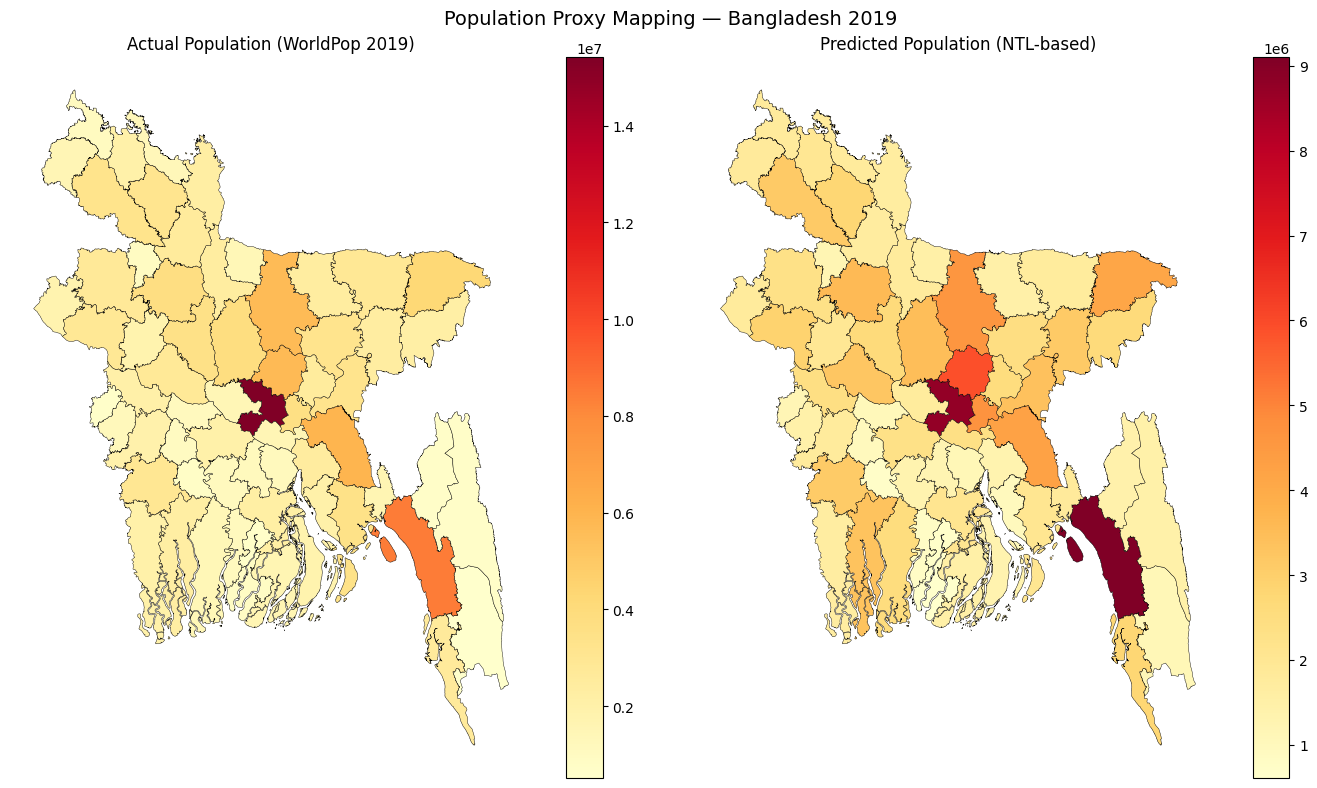

In [ ]:
# Choropleth map Bangladesh
bgd_districts["log_pop"] = np.log1p(bgd_districts["population"])
bgd_districts.loc[df_bgd.index, "rf_pred_pop"] = np.expm1(
    LinearRegression()
    .fit(df_bgd[features_final], df_bgd["log_pop"])
    .predict(df_bgd[features_final])
)

fig, axes = plt.subplots(1, 2, figsize=(14, 8))

bgd_districts.plot(
    column="population", ax=axes[0],
    cmap="YlOrRd", legend=True,
    missing_kwds={"color": "lightgrey"},
    edgecolor="black", linewidth=0.3
)
axes[0].set_title("Actual Population (WorldPop 2019)")
axes[0].axis("off")

bgd_districts.plot(
    column="rf_pred_pop", ax=axes[1],
    cmap="YlOrRd", legend=True,
    missing_kwds={"color": "lightgrey"},
    edgecolor="black", linewidth=0.3
)
axes[1].set_title("Predicted Population (NTL-based)")
axes[1].axis("off")

plt.suptitle("Population Proxy Mapping — Bangladesh 2019", fontsize=14)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/NTL_project/choropleth_bangladesh.png", dpi=150, bbox_inches="tight")
plt.show()

Urban districts: 26
Rural districts: 38

===== BANGLADESH RESULTS (FIXED) =====
Baseline CV R²:      0.5417 ± 0.0951
Stratified CV R²:    0.3888 ± 0.1401
Delta:               -0.1529
p-value:             0.4063
✗ Not significant


In [ ]:
# GADM Nigeria Level 2
url = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_NGA_shp.zip"
zip_path = "/content/gadm41_NGA_shp.zip"
extract_path = "/content/gadm_nigeria"
urllib.request.urlretrieve(url, zip_path)
with zipfile.ZipFile(zip_path, 'r') as z:
    z.extractall(extract_path)

nga_districts = gpd.read_file("/content/gadm_nigeria/gadm41_NGA_2.shp")
print(f"Nigeria LGAs: {len(nga_districts)}")

# WorldPop Nigeria 2019
wp_url = "https://data.worldpop.org/GIS/Population/Global_2000_2020_1km/2019/NGA/nga_ppp_2019_1km_Aggregated.tif"
wp_path = "/content/nga_pop_2019.tif"
r = requests.get(wp_url, stream=True)
print(f"WorldPop status: {r.status_code}")
if r.status_code == 200:
    with open(wp_path, 'wb') as f:
        for chunk in r.iter_content(chunk_size=8192):
            f.write(chunk)
    print("Done")

Nigeria LGAs: 775
WorldPop status: 200
Done


In [ ]:
# NTL zonal stats Nigeria
print("Computing NTL zonal stats for Nigeria...")
nga_geoms = nga_districts.to_crs("EPSG:4326").geometry

nga_ntl_stats = zonal_stats(
    nga_geoms, NTL_PATH,
    stats=["sum", "mean", "max"],
    nodata=0,
    all_touched=False
)

nga_districts["ntl_sum"]  = [s["sum"]  if s["sum"]  is not None else 0 for s in nga_ntl_stats]
nga_districts["ntl_mean"] = [s["mean"] if s["mean"] is not None else 0 for s in nga_ntl_stats]
nga_districts["ntl_max"]  = [s["max"]  if s["max"]  is not None else 0 for s in nga_ntl_stats]
print("NTL done")

# Population zonal stats
print("Computing population zonal stats for Nigeria...")
nga_pop_stats = zonal_stats(
    nga_geoms, wp_path,
    stats=["sum"],
    nodata=-99999,
    all_touched=False
)
nga_districts["population"] = [s["sum"] if s["sum"] is not None else 0 for s in nga_pop_stats]
print("Population done")
print(nga_districts[["NAME_2", "ntl_sum", "population"]].head())

Computing NTL zonal stats for Nigeria...
NTL done
Computing population zonal stats for Nigeria...
Population done
      NAME_2     ntl_sum     population
0  Aba North  213.925797  179779.328125
1  Aba South  279.136353  562466.000000
2  Arochukwu  105.502243  237358.765625
3      Bende   50.873764  276898.718750
4    Ikwuano   19.603645  198259.703125


In [ ]:
# Feature engineering Nigeria
df_nga = nga_districts[["NAME_2", "ntl_sum", "ntl_mean", "ntl_max", "population"]].copy()
df_nga = df_nga[(df_nga["ntl_sum"] > 0) & (df_nga["population"] > 0)]

df_nga["log_ntl_sum"]  = np.log1p(df_nga["ntl_sum"])
df_nga["log_ntl_mean"] = np.log1p(df_nga["ntl_mean"])
df_nga["log_ntl_max"]  = np.log1p(df_nga["ntl_max"])
df_nga["log_pop"]      = np.log1p(df_nga["population"])

# Area
nga_districts["area_km2"] = nga_districts.to_crs("EPSG:3857").geometry.area / 1e6
df_nga["area_km2"] = nga_districts.loc[df_nga.index, "area_km2"]
df_nga["log_area"] = np.log1p(df_nga["area_km2"])

# KMeans urban/rural
kmeans = KMeans(n_clusters=2, random_state=42, n_init=10)
df_nga["urban"] = kmeans.fit_predict(df_nga[["log_ntl_sum", "log_ntl_mean"]])
if df_nga.groupby("urban")["log_ntl_sum"].mean()[0] > df_nga.groupby("urban")["log_ntl_sum"].mean()[1]:
    df_nga["urban"] = 1 - df_nga["urban"]

# Lit fraction
nga_lit_stats = zonal_stats(
    nga_geoms, NTL_PATH,
    stats=["count", "mean", "std"],
    nodata=0,
    all_touched=False
)
nga_districts["lit_fraction"] = [
    (s["mean"] / (s["std"] + 1e-9)) if s["mean"] is not None else 0
    for s in nga_lit_stats
]
df_nga["lit_fraction"] = nga_districts.loc[df_nga.index, "lit_fraction"]

print(f"Districts after cleaning: {len(df_nga)}")
print(f"Urban: {df_nga['urban'].sum()} | Rural: {(df_nga['urban']==0).sum()}")

Districts after cleaning: 695
Urban: 294 | Rural: 401


In [ ]:
# Model - Nigeria
kf = KFold(n_splits=5, shuffle=True, random_state=42)
features_final = ["log_ntl_sum", "log_ntl_mean", "log_ntl_max", "log_area", "lit_fraction"]

strat_nga = []
bl_nga = []

for train_idx, test_idx in kf.split(df_nga):
    train_df = df_nga.iloc[train_idx]
    test_df  = df_nga.iloc[test_idx]

    bl = LinearRegression().fit(
        train_df[["log_ntl_sum","log_ntl_mean","log_ntl_max"]],
        train_df["log_pop"]
    )
    bl_nga.append(r2_score(
        test_df["log_pop"],
        bl.predict(test_df[["log_ntl_sum","log_ntl_mean","log_ntl_max"]])
    ))

    preds = np.zeros(len(test_idx))
    for label in [0, 1]:
        tr = train_df[train_df["urban"] == label]
        te = test_df[test_df["urban"] == label]
        if len(tr) < 5 or len(te) == 0:
            continue
        m = LinearRegression().fit(tr[features_final], tr["log_pop"])
        msk = test_df["urban"] == label
        preds[msk.values] = m.predict(te[features_final])

    valid = preds != 0
    if valid.sum() > 0:
        strat_nga.append(r2_score(test_df["log_pop"].values[valid], preds[valid]))

t_stat, p_val = scipy_stats.ttest_rel(strat_nga, bl_nga)

print("===== NIGERIA RESULTS =====")
print(f"Baseline CV R²:      {np.mean(bl_nga):.4f} ± {np.std(bl_nga):.4f}")
print(f"Stratified CV R²:    {np.mean(strat_nga):.4f} ± {np.std(strat_nga):.4f}")
print(f"Delta:               {np.mean(strat_nga) - np.mean(bl_nga):+.4f}")
print(f"p-value:             {p_val:.4f}")
print("✓ Significant" if p_val < 0.05 else "✗ Not significant")

print("\n===== CROSS-COUNTRY COMPARISON =====")
print(f"India   — Baseline: 0.8289  Stratified: 0.8582  p=0.0267  n=670")
print(f"Nigeria — Baseline: {np.mean(bl_nga):.4f}  Stratified: {np.mean(strat_nga):.4f}  p={p_val:.4f}  n={len(df_nga)}")

===== NIGERIA RESULTS =====
Baseline CV R²:      0.1676 ± 0.0582
Stratified CV R²:    0.2511 ± 0.0693
Delta:               +0.0835
p-value:             0.0039
✓ Significant

===== CROSS-COUNTRY COMPARISON =====
India   — Baseline: 0.8289  Stratified: 0.8582  p=0.0267  n=670
Nigeria — Baseline: 0.1676  Stratified: 0.2511  p=0.0039  n=695
